In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import gcf
from matplotlib import cm, colors
from matplotlib.patches import Patch
from matplotlib_venn import venn2
import os
import pickle
import numpy as np
from tqdm import tqdm

import scipy.stats as stats 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

from scipy.spatial import distance
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


pd.set_option('display.max_columns', None)

In [10]:
# Import baseline and normal livers

counts_dir = '/path/to/'
os.chdir(counts_dir)

raw = pd.read_csv(counts_dir + '/counts_with_norm.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw = raw.iloc[:,5:]
# Change column names
raw.columns = raw.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')
raw.head()

,BSSE_QGF_107054,BSSE_QGF_137770,BSSE_QGF_145455,BSSE_QGF_158634,BSSE_QGF_158637,BSSE_QGF_182102,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,BSSE_QGF_225171,BSSE_QGF_225172,BSSE_QGF_225173,BSSE_QGF_225174,BSSE_QGF_225175,BSSE_QGF_225176,BSSE_QGF_225177,BSSE_QGF_225178,BSSE_QGF_225179,BSSE_QGF_225180,BSSE_QGF_225181,BSSE_QGF_225182,BSSE_QGF_225183,BSSE_QGF_225184,BSSE_QGF_225185,BSSE_QGF_225187,BSSE_QGF_225188,BSSE_QGF_225189,BSSE_QGF_225190,BSSE_QGF_225191,BSSE_QGF_225192,BSSE_QGF_225193,BSSE_QGF_225196,BSSE_QGF_225197,BSSE_QGF_225198,BSSE_QGF_225199,BSSE_QGF_225200,BSSE_QGF_225201,BSSE_QGF_225202,BSSE_QGF_225203,BSSE_QGF_225204,BSSE_QGF_225205,BSSE_QGF_225206,BSSE_QGF_225207,BSSE_QGF_225208,BSSE_QGF_225209,BSSE_QGF_225210,BSSE_QGF_225211,BSSE_QGF_225212,BSSE_QGF_225213,BSSE_QGF_225214,BSSE_QGF_225217,BSSE_QGF_225218,BSSE_QGF_34364,BSSE_QGF_34368,BSSE_QGF_34386,BSSE_QGF_34407,BSSE_QGF_34411,BSSE_QGF_34425,BSSE_QGF_34436,BSSE_QGF_34444,BSSE_QGF_34448,BSSE_QGF_34452,BSSE_QGF_35691,BSSE_QGF_35701,BSSE_QGF_43274,BSSE_QGF_43275,BSSE_QGF_43276,BSSE_QGF_43282,BSSE_QGF_43283,BSSE_QGF_43284,BSSE_QGF_43285,BSSE_QGF_43286,BSSE_QGF_43287,BSSE_QGF_43288,BSSE_QGF_43289,BSSE_QGF_43290,BSSE_QGF_43291,BSSE_QGF_43292,BSSE_QGF_43293,BSSE_QGF_54964,BSSE_QGF_54983,BSSE_QGF_54991,BSSE_QGF_54996,BSSE_QGF_54998,BSSE_QGF_55023,BSSE_QGF_55703,BSSE_QGF_55705,BSSE_QGF_55718,BSSE_QGF_55724,BSSE_QGF_55750,BSSE_QGF_79888,BSSE_QGF_79903,GFB_37104,GFB_37106,GFB_37109,GFB_37110,GFB_37112,GFB_37114,GFB_37116,GFB_37118,GFB_37120,GFB_37122,GFB_37124,GFB_37126,GFB_37128,SRR3898689
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,102,24,137,432,292,312,404,341,283,261,250,330,216,317,419,423,312,456,372,541,178,500,289,505,386,383,442,400,388,356,321,245,295,352,414,305,368,352,307,166,261,332,395,382,398,289,473,378,279,431,315,319,574,108,397,247,273,240,4,416,336,306,329,234,166,56,149,137,195,123,139,331,337,366,295,212,283,449,1152,542,62,211,240,111,162,324,102,107,259,199,146,381,353,313,266,210,284,271,533,363,242,202,236,332,494,77,962
ENSG00000279928,1,0,0,4,1,0,4,0,4,8,0,7,3,7,0,3,5,6,0,0,1,4,3,1,1,1,0,3,8,3,1,2,12,0,8,0,0,1,4,1,1,1,4,2,2,0,1,3,5,3,2,0,6,0,2,3,3,1,0,1,3,1,1,0,0,1,2,0,8,5,5,4,4,0,1,2,0,7,5,2,0,1,2,0,2,0,1,0,0,0,1,0,0,2,2,2,10,0,12,12,0,0,0,2,1,0,1
ENSG00000228037,10,4,4,37,19,10,19,15,19,14,20,20,8,30,25,24,21,31,23,38,19,30,23,22,18,30,25,37,16,36,22,12,24,26,31,14,13,15,28,13,24,19,27,17,35,15,11,24,25,36,24,22,49,6,19,12,11,13,0,15,14,19,22,13,9,9,9,11,19,34,28,15,25,27,34,14,20,30,28,41,7,8,11,28,5,15,10,12,33,22,4,6,11,53,25,16,23,24,72,27,19,1,14,7,22,10,15
ENSG00000142611,11,2,7,135,32,19,39,41,25,19,33,30,14,26,65,71,18,51,47,55,43,82,46,52,24,25,39,46,16,43,19,27,25,31,12,15,34,19,39,15,9,73,33,50,37,28,112,95,47,64,34,83,55,2,22,23,38,14,0,34,88,49,97,6,20,2,0,3,6,3,5,4,5,0,2,6,3,3,26,30,12,62,35,10,0,16,7,20,20,16,9,6,15,84,11,21,56,26,70,24,21,8,16,12,79,6,61
ENSG00000284616,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
raw.shape

(62703, 107)

In [12]:
# Import metadata
meta = pd.read_csv(counts_dir + '/imsig_input_metadata.csv', index_col=0)
meta

,Gender,Baseline biopsy,Sample description
Code,,,
SRR3898689,m,CHC_noHCC,HCC Predict cohort
GFB_37114,f,follow_up,HCC Predict cohort
BSSE_QGF_43287,f,normal_liver,normal_liver
BSSE_QGF_225185,m,CHC_HCC,HCC Predict cohort
BSSE_QGF_43290,m,normal_liver,normal_liver
...,...,...,...
BSSE_QGF_225190,m,CHC_noHCC,HCC Predict cohort
GFB_37118,m,follow_up,HCC Predict cohort
BSSE_QGF_225189,m,CHC_noHCC,HCC Predict cohort


In [13]:
found = []
missing = []
for s in meta.index:
    if s in raw.columns:
        found.append(s)
    else:
        missing.append(s)

print(f'Found: {len(found)}, Missing: {len(missing)}')

Found: 76, Missing: 0


In [14]:
found = []
missing = []
for s in raw.columns:
    if s in meta.index.tolist():
        found.append(s)
    else:
        missing.append(s)

print(f'Found: {len(found)}, Missing: {len(missing)}')

Found: 76, Missing: 31


In [15]:
raw_r = raw.drop(missing, axis=1)

In [21]:
# Filtering

# Create a copy to work on
df_b = raw_r.copy()

# Apply the filter criteria
for col in df_b.columns:
    df_b[col] = np.where(df_b[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_b['Keep'] = np.where(df_b.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_b[df_b.Keep].index

# Return only the rows that were determined to be kept during fitting
df_f = raw_c.loc[keep_indices_].copy()

/scratch/trulss0000/slurm-job.66733733/ipykernel_2633444/2443970300.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_b['Keep'] = np.where(df_b.sum(axis=1) >= 3, True, False)


In [22]:
# Add Gene Biotype Names
with open(os.getenv("HOME") + '/ensemble_mappings_biotype.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_bt = df_f.reset_index(names='Geneid').copy()
    
df_bt['Biotype'] = df_bt['Geneid'].map(loaded_dict)
df_bt.Biotype = df_bt.Biotype.replace('', np.nan)
df_bt.index = df_bt.Geneid
df_bt = df_bt.drop('Geneid', axis=1)

In [23]:
# Only protein coding genes
df_pc = df_bt[df_bt.Biotype == 'protein_coding'].copy()
df_pc = df_pc.drop('Biotype', axis=1)

In [28]:
meta_f

,description,Gender,sample
Code,,,
BSSE_QGF_34380,MetALD,m,Other
BSSE_QGF_34392,MASLD,m,Other
BSSE_QGF_34468,Hepatitis B/ ALD,m,Other
BSSE_QGF_34440,ALD,m,Other
BSSE_QGF_34450,ALD,m,Other
...,...,...,...
BSSE_QGF_225190,HCC Predict cohort,m,CHC_noHCC
GFB_37118,HCC Predict cohort,m,follow_up
BSSE_QGF_225189,HCC Predict cohort,m,CHC_noHCC


# CHC-noHCC/HCC vs Normal

In [31]:
meta_hcv = meta_f[(meta_f['description'] == 'normal_liver') | (meta_f['sample'].str.contains('CHC'))].copy()
meta_hcv

,description,Gender,sample
Code,,,
SRR3898689,HCC Predict cohort,m,CHC_noHCC
BSSE_QGF_43287,normal_liver,f,normal_liver
BSSE_QGF_225185,HCC Predict cohort,m,CHC_HCC
BSSE_QGF_43290,normal_liver,m,normal_liver
BSSE_QGF_43289,normal_liver,m,normal_liver
...,...,...,...
BSSE_QGF_225182,HCC Predict cohort,m,CHC_noHCC
BSSE_QGF_225190,HCC Predict cohort,m,CHC_noHCC
BSSE_QGF_225189,HCC Predict cohort,m,CHC_noHCC


In [32]:
df_pc_hcv = df_pc.loc[:,meta_hcv.index.tolist()].copy()

In [33]:
# Same sorting 
df_pc_t = df_pc_hcv.T.sort_index()

res = list(set(df_pc_t.index) & set(meta_hcv.index))

metadata = meta_hcv.loc[res]

df_pc_t = df_pc_t.loc[res]

In [34]:
# Perform vst normalization

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_pc_t,
    metadata=metadata,
    design_factors=['Gender','description'],
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_pc_t)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_pc_t.index, columns=df_pc_t.columns
)
df_t = transformed_counts.T

/scicore/home/scicore/trulss0000/miniconda3/envs/pipeline_predict_response/lib/python3.12/site-packages/pydeseq2/dds.py:264: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(
Fitting size factors...
... done in 0.07 seconds.

Fitting dispersions...
... done in 4.80 seconds.



In [35]:
dds.vst()

Fit type used for VST : parametric


Fitting dispersions...
... done in 4.86 seconds.



In [36]:
dds.deseq2(fit_type='parametric')

Using parametric fit type.


Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 4.93 seconds.

Fitting dispersion trend curve...
... done in 0.32 seconds.

Fitting MAP dispersions...
... done in 5.89 seconds.

Fitting LFCs...
... done in 2.42 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 106 outlier genes.

Fitting dispersions...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...
... done in 0.12 seconds.



In [37]:
dds.obs

,description,Gender,sample
Code,,,
BSSE_QGF_225212,HCC Predict cohort,f,CHC_HCC
BSSE_QGF_43282,normal-liver,f,normal_liver
BSSE_QGF_43283,normal-liver,m,normal_liver
BSSE_QGF_225203,HCC Predict cohort,f,CHC_noHCC
BSSE_QGF_225218,HCC Predict cohort,m,CHC_HCC
...,...,...,...
BSSE_QGF_225209,HCC Predict cohort,m,CHC_noHCC
BSSE_QGF_225185,HCC Predict cohort,m,CHC_HCC
BSSE_QGF_225190,HCC Predict cohort,m,CHC_noHCC


In [38]:
# cooksCutoff=FALSE, independentFiltering=FALSE
ds = DeseqStats(dds, contrast=['description', 'HCC Predict cohort', 'normal-liver'],
                cooks_filter=False, independent_filter=False)

In [39]:
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: description HCC Predict cohort vs normal-liver
                   baseMean  log2FoldChange     lfcSE       stat  \
Geneid                                                             
ENSG00000160072  351.077269       -0.532240  0.160940  -3.307064   
ENSG00000142611   28.827418        1.897052  0.285038   6.655442   
ENSG00000157911  297.760141       -0.162831  0.125888  -1.293453   
ENSG00000142655  518.961051       -0.459191  0.132628  -3.462242   
ENSG00000149527  120.133850        0.276651  0.266141   1.039492   
...                     ...             ...       ...        ...   
ENSG00000276345   37.248022       -0.849025  1.336375  -0.635319   
ENSG00000275063  390.588181        3.854933  0.457355   8.428750   
ENSG00000277856  189.192060        4.913207  0.476213  10.317254   
ENSG00000271254  297.923089       -0.604542  0.152222  -3.971446   
ENSG00000277475    5.122125       -0.597156  0.392324  -1.522101   

                       pvalue 

... done in 41.43 seconds.



In [40]:
df_res_hcv = ds.results_df
df_res_hcv['abs_diff'] = df_res_hcv.log2FoldChange.abs()
df_res_hcv = df_res_hcv.sort_values('abs_diff', ascending=False)

In [41]:
# Get anootations from ensemble
with open(os.getenv("HOME") + '/ensemble_mappings_gene.pkl', 'rb') as f:
    ensembl_dict = pickle.load(f)
    
df_res_hcv['Gene_name'] = df_res_hcv.index.map(ensembl_dict)

In [42]:
df_res_hcv.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene_name
Geneid,,,,,,,,
ENSG00000264424,411.613241,9.005783,0.921801,9.769774,1.517897e-22,5.163015e-21,9.005783,MYH4
ENSG00000268916,26.953675,6.601914,1.009442,6.540159,6.145329e-11,3.893518e-10,6.601914,CSAG3
ENSG00000181617,16.232270,6.063331,1.148223,5.280623,1.287452e-07,4.988801e-07,6.063331,FDCSP
ENSG00000104435,204.530878,5.995436,0.491690,12.193530,3.365238e-34,5.456586e-32,5.995436,STMN2
ENSG00000101210,183.783753,5.919294,0.666011,8.887687,6.239414e-19,1.247198e-17,5.919294,EEF1A2


In [43]:
df_res_hcv['sig'] = np.where(df_res_hcv.padj < 0.05, True, False)

# Baseline

In [44]:
# Baseline DEGs
revised_dir = "/path/to/"
os.chdir(revised_dir)

df_baseline = pd.read_csv('Baseline_sig_degs_with_hm_reactome_251125.csv', index_col=0)

df_baseline.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,Hallmark,Reactome
Geneid,,,,,,,,,,
ENSG00000121871,48.448299,-3.335657,0.770559,-4.328879,0.000015,0.006215,3.335657,SLITRK3,NaN,NaN
ENSG00000165841,3634.976924,-2.281461,0.547173,-4.169545,0.000031,0.007373,2.281461,CYP2C19,NaN,NaN
ENSG00000091138,76.030001,2.103508,0.522340,4.027084,0.000056,0.009489,2.103508,SLC26A3,NaN,NaN
ENSG00000173702,362.609388,2.012033,0.473098,4.252890,0.000021,0.006900,2.012033,MUC13,NaN,NaN
ENSG00000204669,4.034931,1.963120,0.648626,3.026583,0.002473,0.039375,1.963120,C9orf57,NaN,NaN


In [45]:
df_baseline.shape

(1347, 10)

In [46]:
df_baseline[df_baseline.padj < 0.05].shape

(1347, 10)

In [47]:
mapped_lfc = df_baseline.index.map(
    df_res_hcv.log2FoldChange
)

# Same direction: sign(df) == sign(mapped results)
same_direction = np.sign(df_baseline.log2FoldChange) == np.sign(mapped_lfc)

df_baseline['same_direction'] = same_direction

In [48]:
df_baseline[df_baseline['same_direction'] == False].shape

(111, 11)

In [49]:
df_baseline['log2FoldChange_hcv'] = df_res_hcv.log2FoldChange

In [50]:
df_res_hcv.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene_name,sig
Geneid,,,,,,,,,
ENSG00000264424,411.613241,9.005783,0.921801,9.769774,1.517897e-22,5.163015e-21,9.005783,MYH4,True
ENSG00000268916,26.953675,6.601914,1.009442,6.540159,6.145329e-11,3.893518e-10,6.601914,CSAG3,True
ENSG00000181617,16.232270,6.063331,1.148223,5.280623,1.287452e-07,4.988801e-07,6.063331,FDCSP,True
ENSG00000104435,204.530878,5.995436,0.491690,12.193530,3.365238e-34,5.456586e-32,5.995436,STMN2,True
ENSG00000101210,183.783753,5.919294,0.666011,8.887687,6.239414e-19,1.247198e-17,5.919294,EEF1A2,True


In [51]:
df_baseline['hcv_sig'] = df_res_hcv.sig

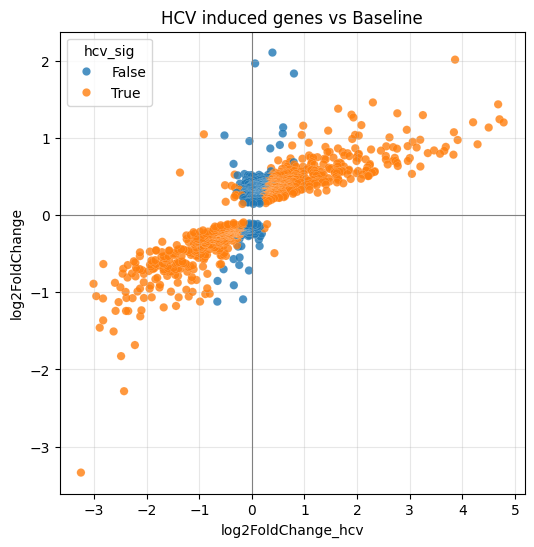

In [52]:
plt.figure(figsize=(6, 6))
ax = sns.scatterplot(
    data=df_baseline,
    x="log2FoldChange_hcv",
    y="log2FoldChange",
    hue='hcv_sig',
    linewidth=0.1,
    alpha=0.8,
)

plt.title(f"HCV induced genes vs Baseline")
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.grid(alpha=0.3)

# ===== Annotate outliers =====
# outliers = df_res_hcc[
#     (df_res_hcc["log2FoldChange"] < -6) |
#     (df_res_hcc["log2FoldChange"] > 6) |
#     (df_res_hcc["log2FoldChange_nohcc"] < -6) |
#     (df_res_hcc["log2FoldChange_nohcc"] > 6)
# ]

# for _, row in outliers.iterrows():
#     ax.text(
#         row["log2FoldChange"],
#         row["log2FoldChange_nohcc"],
#         row["Gene_name"],
#         fontsize=8,
#         ha='right',
#         va='bottom'
#     ) 
plt.show()
#plt.savefig(f'Scatter_ULD_{r}.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [53]:
df_baseline.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,Hallmark,Reactome,same_direction,log2FoldChange_hcv,hcv_sig
Geneid,,,,,,,,,,,,,
ENSG00000121871,48.448299,-3.335657,0.770559,-4.328879,0.000015,0.006215,3.335657,SLITRK3,NaN,NaN,True,-3.250471,True
ENSG00000165841,3634.976924,-2.281461,0.547173,-4.169545,0.000031,0.007373,2.281461,CYP2C19,NaN,NaN,True,-2.430194,True
ENSG00000091138,76.030001,2.103508,0.522340,4.027084,0.000056,0.009489,2.103508,SLC26A3,NaN,NaN,True,0.390703,False
ENSG00000173702,362.609388,2.012033,0.473098,4.252890,0.000021,0.006900,2.012033,MUC13,NaN,NaN,True,3.862532,True
ENSG00000204669,4.034931,1.963120,0.648626,3.026583,0.002473,0.039375,1.963120,C9orf57,NaN,NaN,True,0.061689,False


In [54]:
df_res_hcv[df_res_hcv.padj < 0.05].shape

(10867, 9)

In [55]:
df_res_hcv[df_res_hcv.padj < 0.05].Gene_name.isna().sum()

np.int64(0)

In [56]:
len(set(df_res_hcv[df_res_hcv.padj < 0.05].Gene_name))

10761

In [57]:
len(set(df_baseline.Gene))

1347

In [58]:
df_baseline[df_baseline.hcv_sig == True].shape

(986, 13)

In [59]:
df_baseline.index

Index(['ENSG00000121871', 'ENSG00000165841', 'ENSG00000091138',
       'ENSG00000173702', 'ENSG00000204669', 'ENSG00000099812',
       'ENSG00000186487', 'ENSG00000164742', 'ENSG00000108231',
       'ENSG00000174564',
       ...
       'ENSG00000177479', 'ENSG00000127483', 'ENSG00000084463',
       'ENSG00000110713', 'ENSG00000259956', 'ENSG00000158796',
       'ENSG00000198231', 'ENSG00000099783', 'ENSG00000204120',
       'ENSG00000161217'],
      dtype='object', name='Geneid', length=1347)

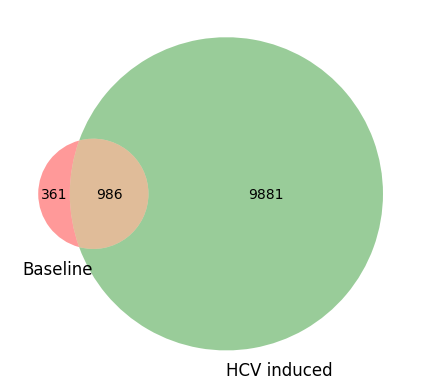

In [60]:
venn2([set(df_baseline.index), set(df_res_hcv[df_res_hcv.padj < 0.05].index)], set_labels = ('Baseline', 'HCV induced'))
plt.savefig('venn_Baseline_vs_hcv_induced.pdf', bbox_inches='tight', dpi=300)

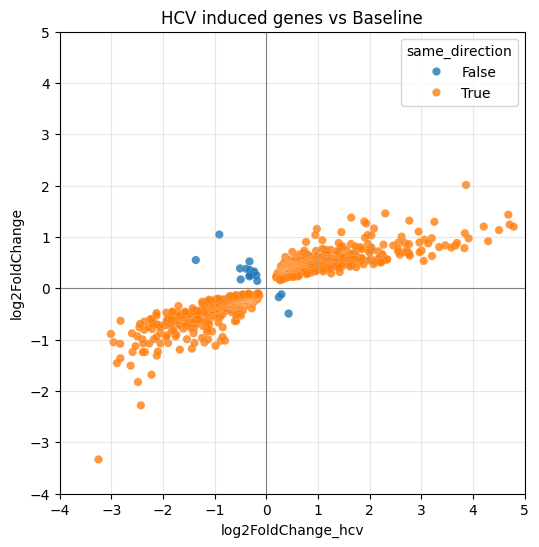

In [61]:
plt.figure(figsize=(6, 6))
ax = sns.scatterplot(
    data=df_baseline[df_baseline.hcv_sig == True],
    x="log2FoldChange_hcv",
    y="log2FoldChange",
    hue='same_direction',
    linewidth=0.1,
    alpha=0.8,
)

plt.title(f"HCV induced genes vs Baseline")
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.grid(alpha=0.3)

plt.xlim(-4,5)
plt.ylim(-4,5)

plt.savefig('scatter_baseline_hcv_induced.pdf', bbox_inches='tight', dpi=300)
#plt.show()

In [62]:
df_baseline[(df_baseline.hcv_sig == True) & (df_baseline.same_direction == False)].shape

(17, 13)

In [63]:
df_baseline[(df_baseline.hcv_sig == True) & (df_baseline.same_direction == False)].shape

(17, 13)

In [64]:
df_baseline[(df_baseline.hcv_sig == True) & (df_baseline.same_direction == False)].to_csv('table_baseline_hcv_induced_different_direction.csv')

In [65]:
df_baseline[df_baseline.padj < 0.05].shape

(1347, 13)

In [66]:
#df_hcv_base = df_baseline[(df_baseline.hcv_sig == True) & (df_baseline.same_direction == True)].copy()

# We take the overlap regardless of direction
df_hcv_base = df_baseline[(df_baseline.hcv_sig == True)].copy()

In [67]:
df_hcv_base.shape

(986, 13)

In [68]:
df_hcv_base.head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,Hallmark,Reactome,same_direction,log2FoldChange_hcv,hcv_sig
Geneid,,,,,,,,,,,,,
ENSG00000121871,48.448299,-3.335657,0.770559,-4.328879,0.000015,0.006215,3.335657,SLITRK3,NaN,NaN,True,-3.250471,True
ENSG00000165841,3634.976924,-2.281461,0.547173,-4.169545,0.000031,0.007373,2.281461,CYP2C19,NaN,NaN,True,-2.430194,True
ENSG00000173702,362.609388,2.012033,0.473098,4.252890,0.000021,0.006900,2.012033,MUC13,NaN,NaN,True,3.862532,True
ENSG00000186487,6.203493,-1.827540,0.568039,-3.217281,0.001294,0.029632,1.827540,MYT1L,NaN,NaN,True,-2.486947,True
ENSG00000164742,4545.440755,-1.684218,0.437670,-3.848144,0.000119,0.012383,1.684218,ADCY1,['HALLMARK_ESTROGEN_RESPONSE_EARLY'],NaN,True,-2.224212,True
ENSG00000108231,47.720975,-1.508281,0.474558,-3.178287,0.001481,0.031485,1.508281,LGI1,NaN,NaN,True,-2.628995,True
ENSG00000174564,101.809871,-1.459068,0.412164,-3.540016,0.000400,0.018734,1.459068,IL20RB,NaN,NaN,True,-2.892663,True
ENSG00000077279,13.838431,1.457836,0.501861,2.904861,0.003674,0.048131,1.457836,DCX,['HALLMARK_PANCREAS_BETA_CELLS'],NaN,True,2.300463,True
ENSG00000196859,25.388570,1.433237,0.413122,3.469280,0.000522,0.020975,1.433237,KRT39,NaN,NaN,True,4.681549,True


### Baseline vs FU paired

In [ ]:
meta_fu = pd.read_csv('Sample_mapping_follow_up.csv', index_col=0)
meta_fu.head()

In [70]:
df_fu = pd.read_csv('chcHCC_vs_fu_paired_221225.csv', index_col=0)
df_fu.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene_name
ENSG00000198930,17.923189,-5.104655,0.914114,-5.584263,2.346937e-08,1.202416e-06,5.104655,CSAG1
ENSG00000198033,3.338853,4.864227,1.602520,3.035361,2.402477e-03,1.189593e-02,4.864227,TUBA3C
ENSG00000173432,40166.163188,4.585929,0.739793,6.198939,5.684499e-10,5.275540e-08,4.585929,SAA1
ENSG00000132693,77153.962399,4.534175,0.717255,6.321570,2.589198e-10,2.730595e-08,4.534175,CRP
ENSG00000196834,4.489761,4.184897,1.319710,3.171072,1.518773e-03,8.372843e-03,4.184897,POTEI


In [71]:
df_hcv_base['log2FoldChange_fu'] = df_fu.log2FoldChange
df_hcv_base['padj_fu'] = df_fu.padj

In [72]:
df_hcv_base.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,Hallmark,Reactome,same_direction,log2FoldChange_hcv,hcv_sig,log2FoldChange_fu,padj_fu
Geneid,,,,,,,,,,,,,,,
ENSG00000121871,48.448299,-3.335657,0.770559,-4.328879,0.000015,0.006215,3.335657,SLITRK3,NaN,NaN,True,-3.250471,True,2.025468,0.021488
ENSG00000165841,3634.976924,-2.281461,0.547173,-4.169545,0.000031,0.007373,2.281461,CYP2C19,NaN,NaN,True,-2.430194,True,1.459915,0.026142
ENSG00000173702,362.609388,2.012033,0.473098,4.252890,0.000021,0.006900,2.012033,MUC13,NaN,NaN,True,3.862532,True,-0.793915,0.340126
ENSG00000186487,6.203493,-1.827540,0.568039,-3.217281,0.001294,0.029632,1.827540,MYT1L,NaN,NaN,True,-2.486947,True,NaN,NaN
ENSG00000164742,4545.440755,-1.684218,0.437670,-3.848144,0.000119,0.012383,1.684218,ADCY1,['HALLMARK_ESTROGEN_RESPONSE_EARLY'],NaN,True,-2.224212,True,1.732712,0.002640


In [73]:
df_hcv_base['fu_sig'] = np.where(df_hcv_base.padj_fu < 0.05, True, False)

In [74]:
df_hcv_base.shape

(986, 16)

In [75]:
len(set(df_baseline.Gene))

1347

In [76]:
len(set(df_fu[df_fu.padj < 0.05].Gene_name))

5079

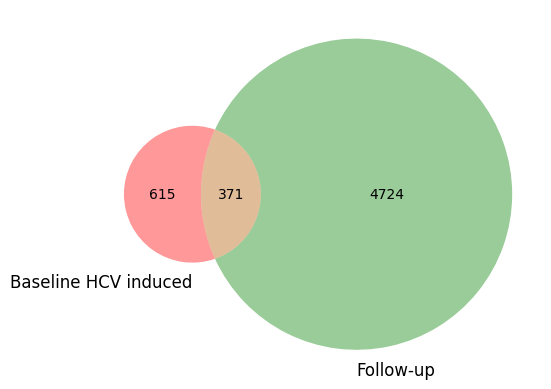

In [77]:
venn2([set(df_hcv_base.index), set(df_fu[df_fu.padj < 0.05].index)], set_labels = ('Baseline HCV induced', 'Follow-up'))
plt.savefig('venn_Base_hcv_induced_FU.pdf', bbox_inches='tight', dpi=300)

In [78]:
mapped_lfc = df_hcv_base.index.map(
    df_fu.log2FoldChange
)

# Same direction: sign(df) == sign(mapped results)
same_direction = np.sign(df_hcv_base.log2FoldChange) == np.sign(mapped_lfc)

df_hcv_base['same_direction'] = same_direction

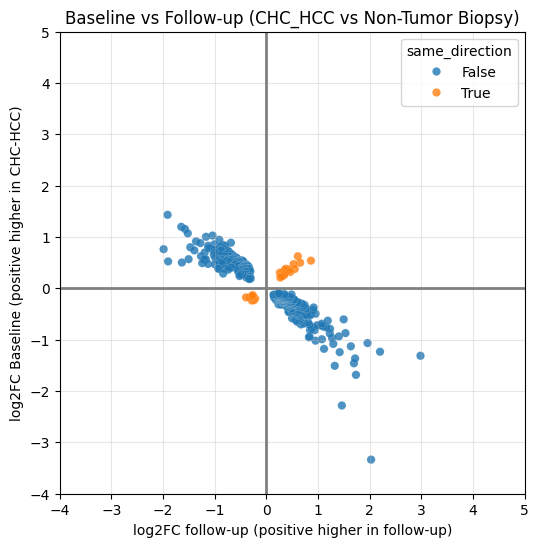

In [79]:
plt.figure(figsize=(6, 6))
ax = sns.scatterplot(
    data=df_hcv_base[df_hcv_base.fu_sig == True],
    x="log2FoldChange_fu",
    y="log2FoldChange",
    hue='same_direction',
    linewidth=0.1,
    alpha=0.8,
)

plt.title(f"Baseline vs Follow-up (CHC_HCC vs Non-Tumor Biopsy)")
plt.axhline(0, color="grey", linewidth=2)
plt.axvline(0, color="grey", linewidth=2)
plt.grid(alpha=0.3)

plt.xlim(-4,5)
plt.ylim(-4,5)

plt.ylabel('log2FC Baseline (positive higher in CHC-HCC)')
plt.xlabel('log2FC follow-up (positive higher in follow-up)')

plt.savefig('scatter_base_hcv_induced_fu.pdf', bbox_inches='tight', dpi=300)
#plt.show()

In [124]:
df_hcv_base[(df_hcv_base.same_direction == True) & (df_hcv_base.fu_sig == True)].shape

(24, 16)

In [119]:
df_hcv_base[(df_hcv_base.same_direction == True) & (df_hcv_base.fu_sig == True) | (df_hcv_base.fu_sig == False)]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,Hallmark,Reactome,same_direction,log2FoldChange_hcv,hcv_sig,log2FoldChange_fu,padj_fu,fu_sig
Geneid,,,,,,,,,,,,,,,,
ENSG00000173702,362.609388,2.012033,0.473098,4.252890,0.000021,0.006900,2.012033,MUC13,NaN,NaN,False,3.862532,True,-0.793915,0.340126,False
ENSG00000186487,6.203493,-1.827540,0.568039,-3.217281,0.001294,0.029632,1.827540,MYT1L,NaN,NaN,False,-2.486947,True,NaN,NaN,False
ENSG00000077279,13.838431,1.457836,0.501861,2.904861,0.003674,0.048131,1.457836,DCX,['HALLMARK_PANCREAS_BETA_CELLS'],NaN,False,2.300463,True,-0.380040,0.728455,False
ENSG00000158014,28.562048,1.376624,0.367305,3.747908,0.000178,0.014595,1.376624,SLC30A2,NaN,NaN,False,1.640211,True,-1.045740,0.099286,False
ENSG00000175879,9.171516,1.317220,0.332579,3.960625,0.000075,0.010085,1.317220,HOXD8,NaN,NaN,False,2.764809,True,-0.515155,0.477113,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000145916,1623.063521,-0.134873,0.040528,-3.327906,0.000875,0.025857,0.134873,RMND5B,NaN,NaN,True,-0.184607,True,-0.142531,0.052746,False
ENSG00000120800,2494.503974,-0.134503,0.046243,-2.908599,0.003631,0.047748,0.134503,UTP20,['HALLMARK_MYC_TARGETS_V2'],NaN,False,-0.233497,True,0.171214,0.089767,False
ENSG00000065029,1477.377754,-0.130696,0.044363,-2.946075,0.003218,0.044814,0.130696,ZNF76,NaN,NaN,True,-0.324695,True,-0.135813,0.127092,False


In [120]:
#df_hcv_base[(df_hcv_base.same_direction == True) & (df_hcv_base.fu_sig == True) | (df_hcv_base.fu_sig == False)].to_csv('base_hcv_induced_persistant_27112025.csv')

df_hcv_base[df_hcv_base.fu_sig == False].to_csv('base_hcv_induced_persistant_22122025.csv')

In [122]:
df_hcv_base[df_hcv_base.Gene == 'XCL1']

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,Hallmark,Reactome,same_direction,log2FoldChange_hcv,hcv_sig,log2FoldChange_fu,padj_fu,fu_sig
Geneid,,,,,,,,,,,,,,,,
ENSG00000143184,151.805137,0.816817,0.186433,4.38128,0.000012,0.006009,0.816817,XCL1,['HALLMARK_INTERFERON_GAMMA_RESPONSE'],NaN,False,1.478052,True,-0.887591,0.006906,True


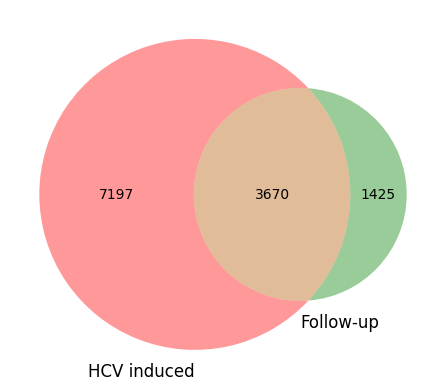

In [121]:
venn2([set(df_res_hcv[df_res_hcv.padj < 0.05].index), set(df_fu[df_fu.padj < 0.05].index)], set_labels = ('HCV induced', 'Follow-up'))
plt.savefig('venn_hcv_induced_vs_FU.pdf', bbox_inches='tight', dpi=300)